<a href="https://colab.research.google.com/github/VedantM-07/Stroke_Risk_Analysis_Prediction/blob/main/Stroke_risk_factor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [54]:
conn = sqlite3.connect(':memory:')

In [55]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df.to_sql("stroke_data", conn, index=False, if_exists='replace')


5110

In [56]:
query = """
SELECT *
FROM stroke_data
WHERE age > 50 AND hypertension = 1;
"""

result = pd.read_sql(query, conn)
result


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
1,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
2,12109,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1
3,34120,Male,75.0,1,0,Yes,Private,Urban,221.29,25.8,smokes,1
4,13861,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
398,67012,Male,64.0,1,0,Yes,Private,Rural,196.26,34.5,Unknown,0
399,22190,Female,64.0,1,0,Yes,Self-employed,Urban,76.89,30.2,Unknown,0
400,6369,Male,59.0,1,0,Yes,Private,Rural,95.05,30.9,never smoked,0
401,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0


In [57]:
quary = """
SELECT stroke,
       AVG(bmi) AS avg_bmi,
       AVG(avg_glucose_level) AS avg_glucose
FROM stroke_data
GROUP BY stroke;
"""

result = pd.read_sql(quary, conn)
result


,stroke,avg_bmi,avg_glucose
0,0,28.823064,104.795513
1,1,30.471292,132.544739


In [58]:
quary = """
SELECT *,
       CASE
           WHEN age > 60 AND hypertension = 1 THEN 'High Risk'
           WHEN age > 40 THEN 'Moderate Risk'
           ELSE 'Low Risk'
       END AS risk_category
FROM stroke_data;
"""

result = pd.read_sql(quary, conn)
result

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,risk_category
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Moderate Risk
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Moderate Risk
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Moderate Risk
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Moderate Risk
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0,High Risk
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Moderate Risk
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Low Risk
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Moderate Risk


In [59]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [60]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 1.6 MB


In [61]:
print('rows:'+ str(df.shape[0]))
print('columns:' + str(df.shape[1]))

rows:5110
columns:12


In [62]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [63]:
df[df['bmi'].isnull()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


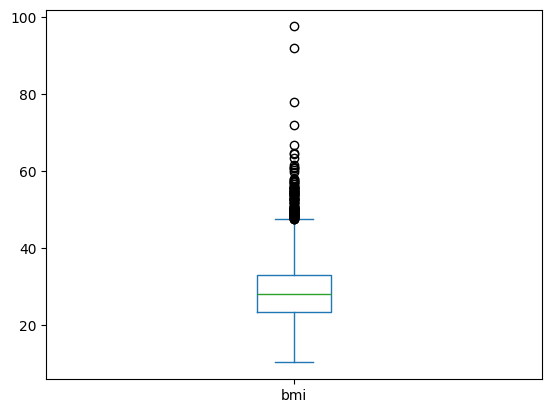

In [64]:
df['bmi'].plot(kind = 'box');

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df['bmi'].mean().round(1)

np.float64(28.9)

In [67]:
df['bmi'].fillna(df['bmi'].mean().round(1), inplace = True)

In [68]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.9,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.9,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [69]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [70]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893503,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.698018,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [71]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.9,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.9,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [72]:
df['stroke'] = df['stroke'].apply(lambda x: 'YES' if x == 1 else 'NO')

In [73]:
df


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,YES
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.9,never smoked,YES
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,YES
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,YES
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,YES
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.9,never smoked,NO
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,NO
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,NO
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,NO


In [74]:
Categorical_Columns = df.select_dtypes(exclude = np.number).columns

In [75]:
Categorical_Columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status', 'stroke'],
      dtype='object')

In [76]:
Numeric_Columns = df.select_dtypes(include = np.number).columns

In [77]:
Numeric_Columns


Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi'],
      dtype='object')

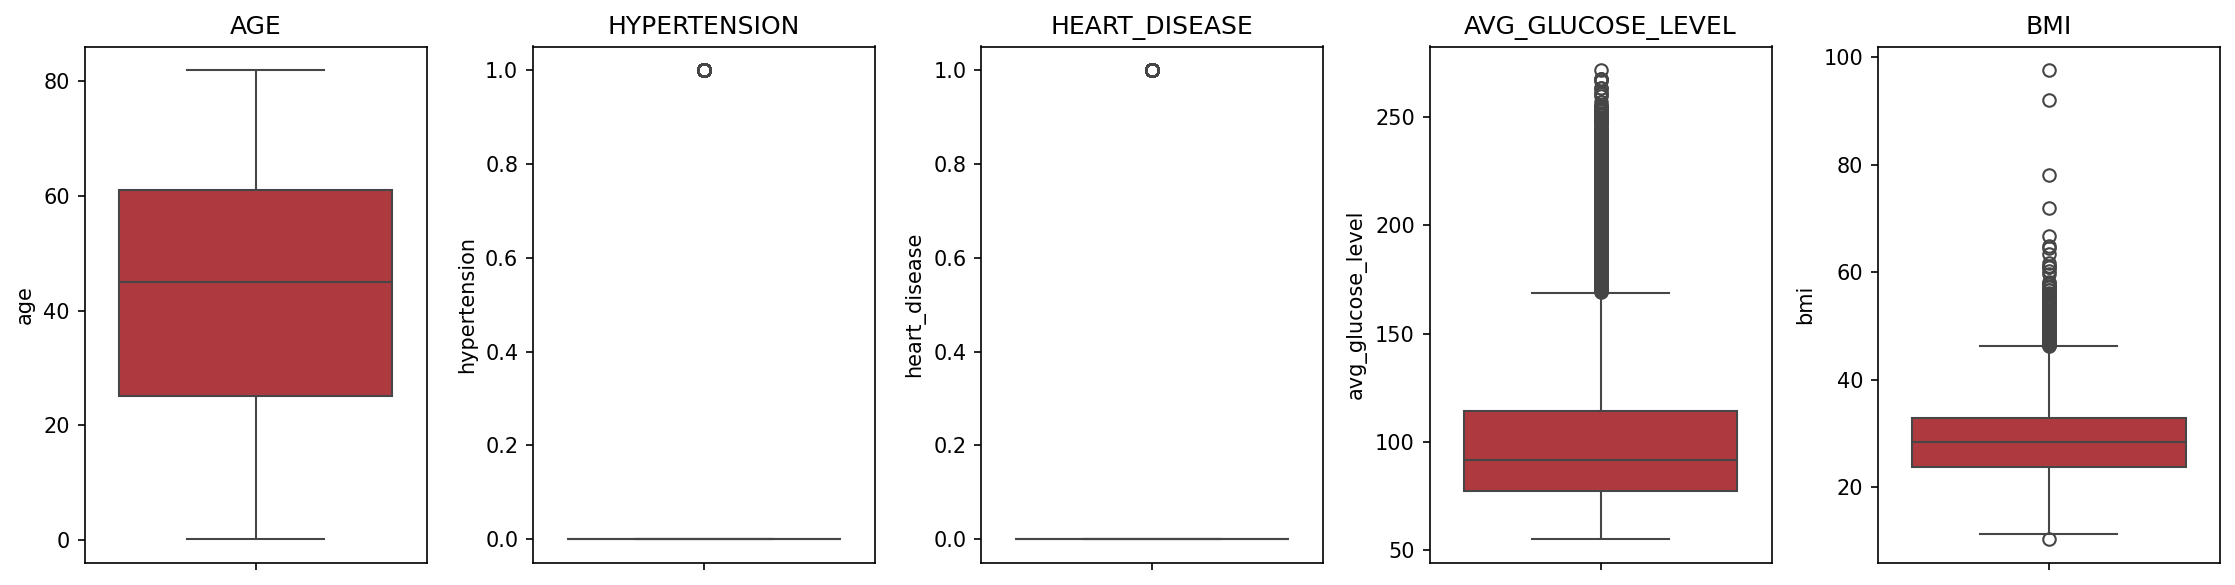

In [78]:
fig, axes = plt.subplots(ncols = 5, figsize = (15,4), dpi = 150)

for col, axis in zip(Numeric_Columns[1:], axes):
    sns.boxplot(data = df[col], ax = axis, color='#c1272d')
    axis.set_title(col.upper())

plt.tight_layout();

In [79]:
Numeric_Columns.to_list()

['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

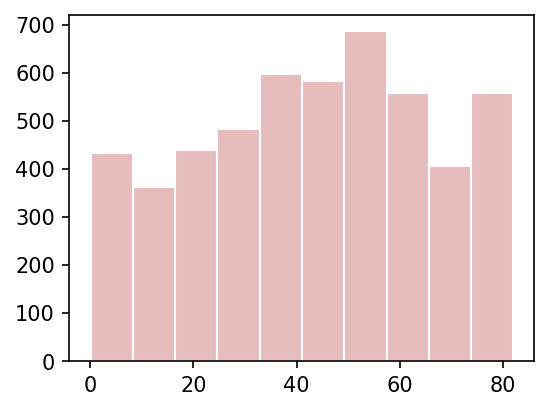

In [80]:
plt.figure(figsize = (4,3), dpi = 150)

plt.hist(df['age'], edgecolor = 'white', color = '#e7bcbc');

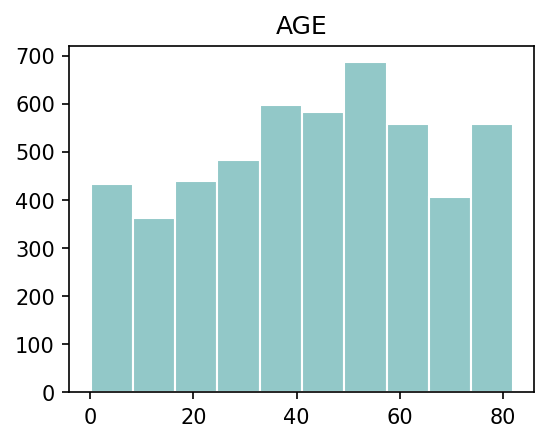

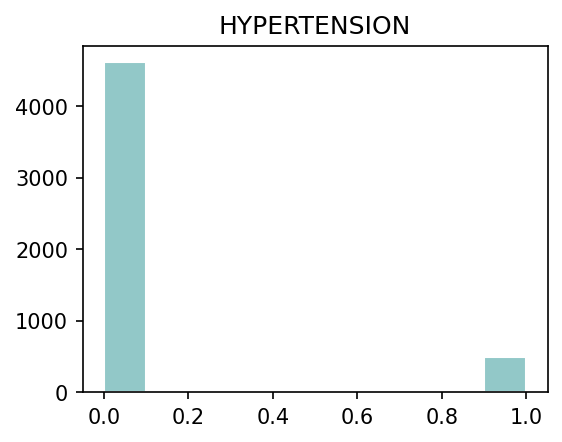

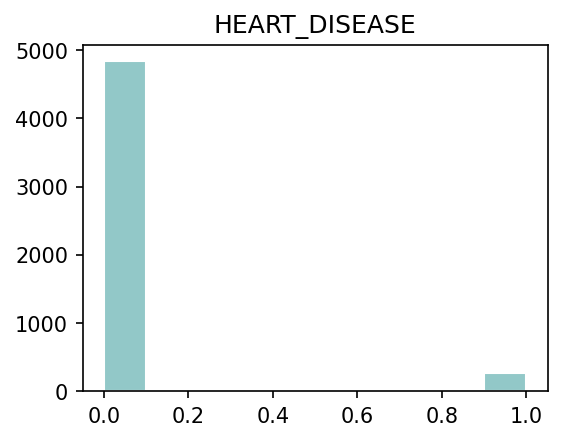

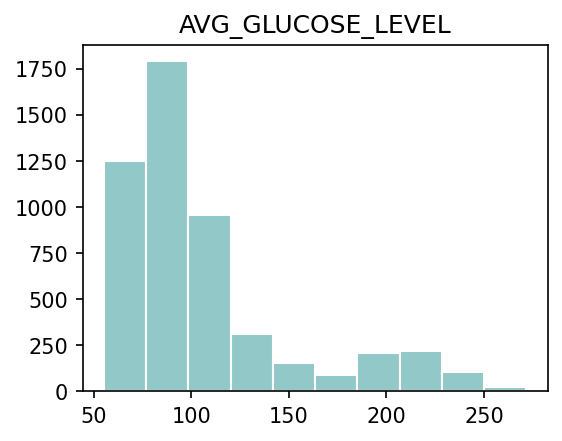

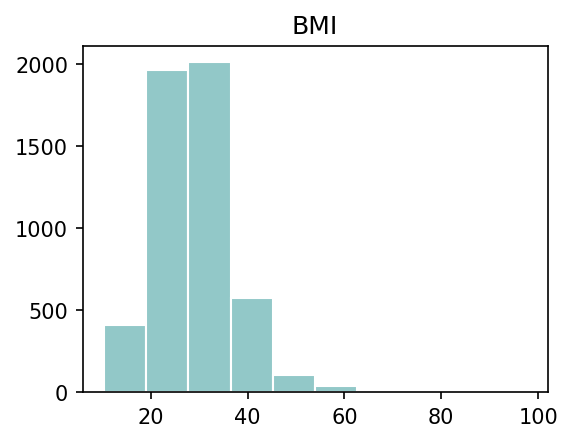

In [81]:
for col in Numeric_Columns[1:]:
    plt.figure(figsize=(4,3), dpi = 150)
    plt.hist(df[col], edgecolor = 'white', color = '#92c8c8')
    plt.title(col.upper())

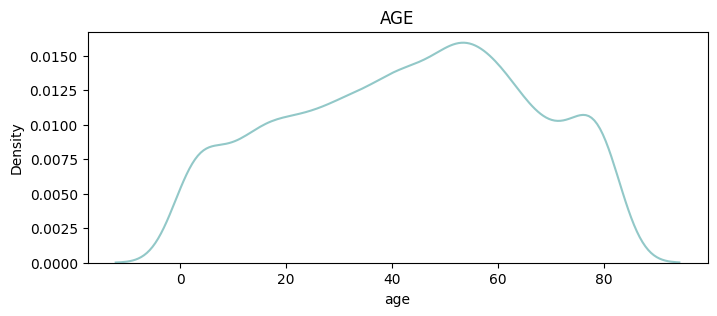

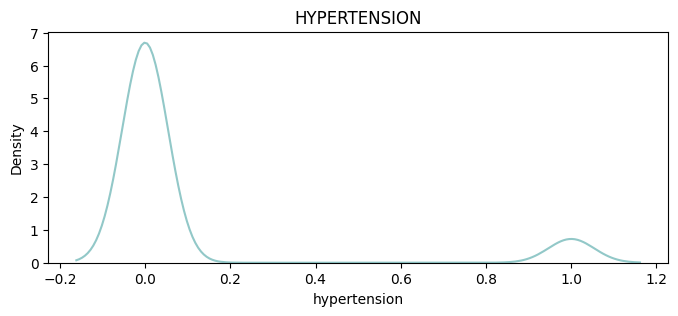

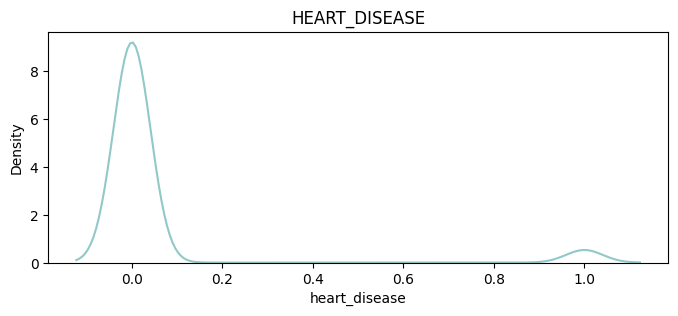

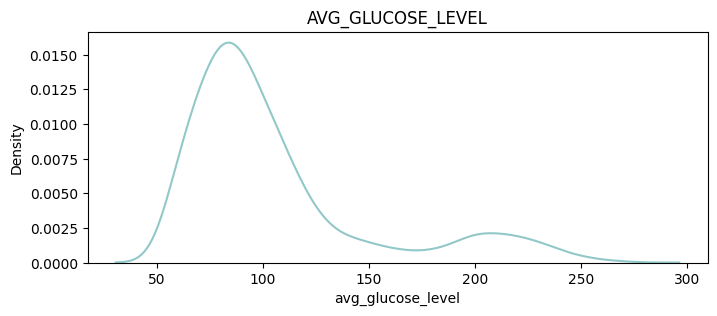

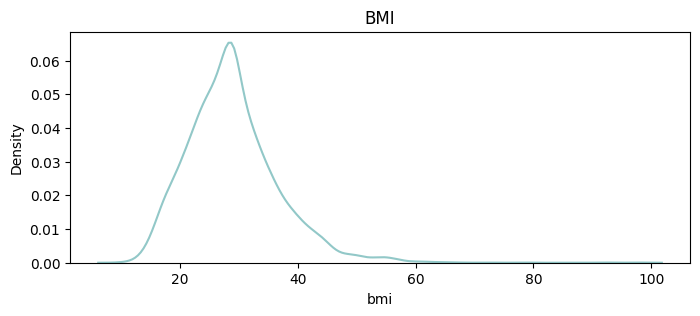

In [82]:
for col in Numeric_Columns[1:]:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data = df[col], color = '#92c8c8')
    plt.title(col.upper())

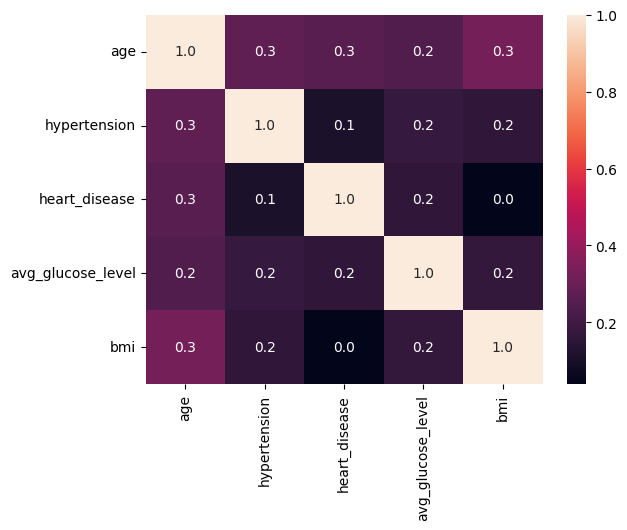

In [83]:
correlation_matrix = df[Numeric_Columns[1:]].corr()
sns.heatmap(correlation_matrix, annot = True, fmt = '0.1f');

In [84]:
df[Categorical_Columns].columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status', 'stroke'],
      dtype='object')

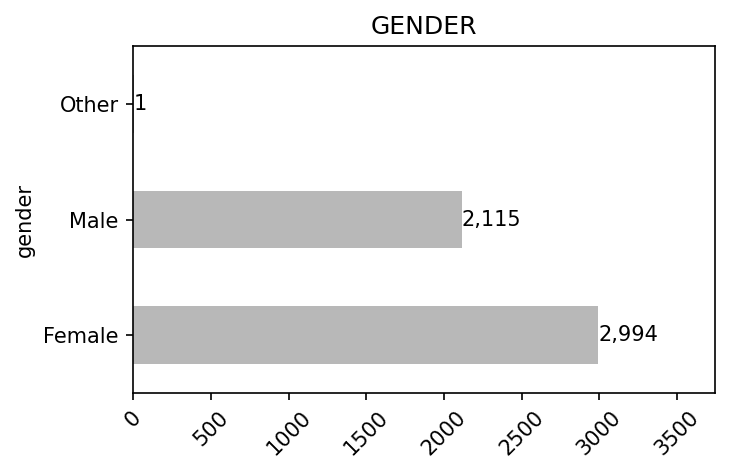

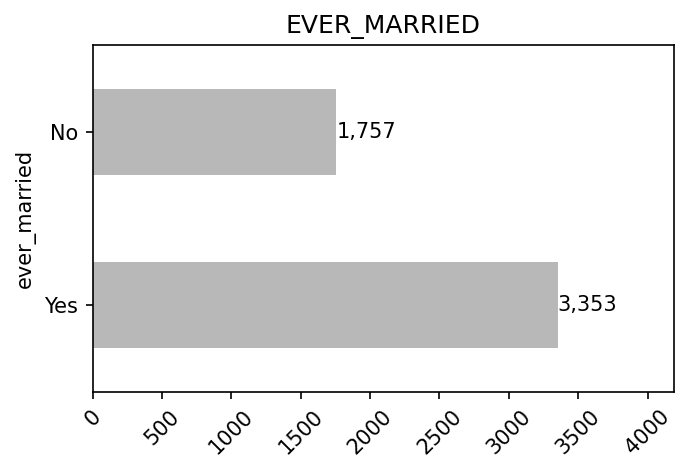

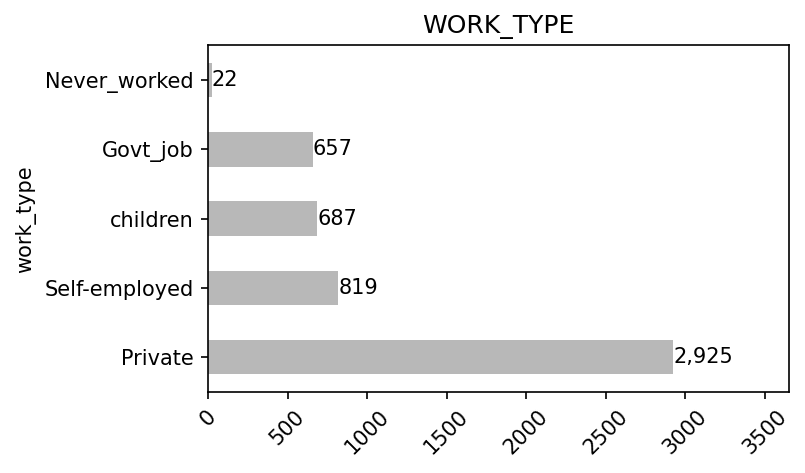

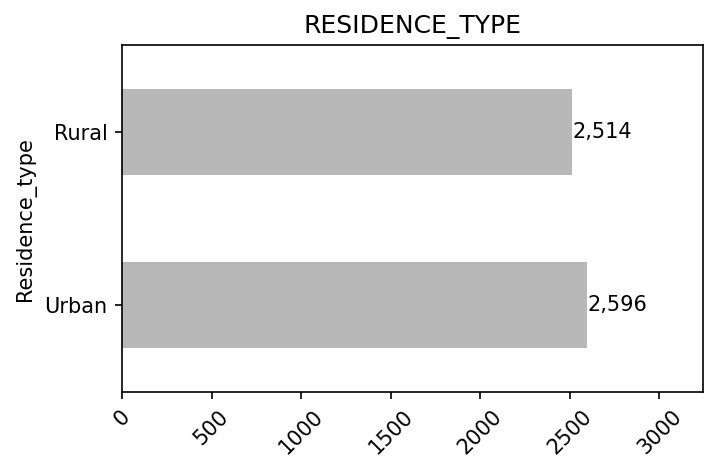

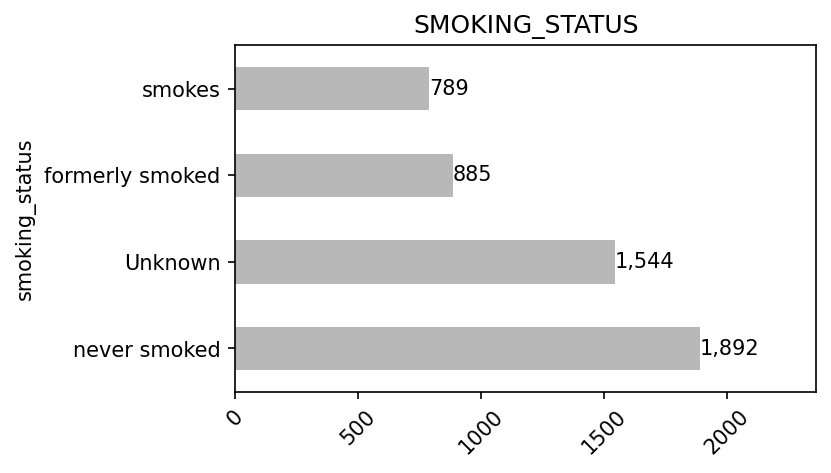

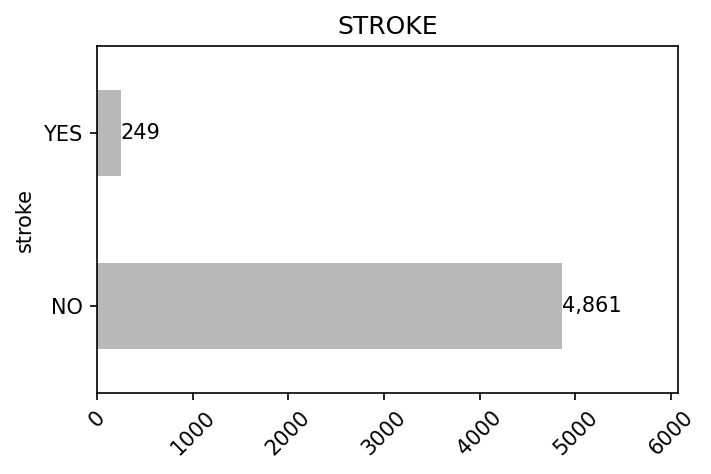

In [85]:
for col in Categorical_Columns:
    plt.figure(figsize=(5, 3), dpi = 150)
    ax = df[col].value_counts().plot(kind = 'barh', color = '#b8b8b8')
    ax.margins(x=0.25)
    plt.title(col.upper())
    plt.xticks(rotation = 45)
    for i in ax.containers:
        ax.bar_label(i, fmt = '{:,.0f}');

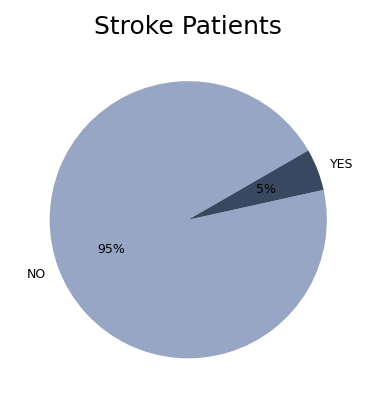

In [86]:
plt.figure(figsize = (4, 3), dpi = 150)
df['stroke'].value_counts().plot(
    kind = 'pie',
    autopct = "%0.0f%%",
    startangle = 30,
    title = 'Stroke Patients',
    fontsize = 6,
    colors = ['#97a6c4', '#384860']
)
plt.ylabel('');

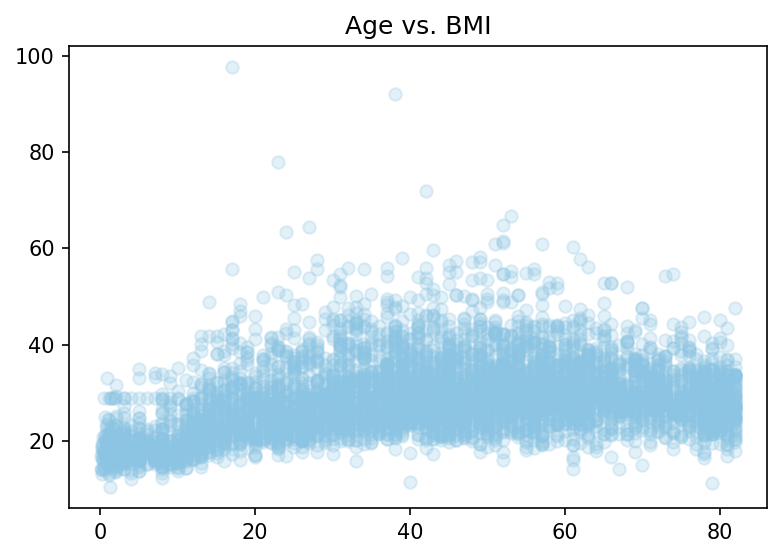

In [87]:
plt.figure(figsize=(6,4), dpi = 150)
plt.title('Age vs. BMI')
plt.scatter(x = df['age'], y = df['bmi'], alpha = 0.25, color = '#8cc5e3');

In [88]:
df = df.drop("id", axis=1)

In [89]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df["bmi"] = imputer.fit_transform(df[["bmi"]])

In [90]:
df = pd.get_dummies(df, columns=["gender", "ever_married", "work_type", "Residence_type", "smoking_status"], drop_first=True)

In [91]:
from sklearn.model_selection import train_test_split

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=200)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [93]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[971   1]
 [ 50   0]]

Classification Report:
               precision    recall  f1-score   support

          NO       0.95      1.00      0.97       972
         YES       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC Score: 0.7964711934156379
